# NYC HVFHV — Exploratory Data Analysis

Explores temporal, spatial, and behavioral patterns in the cleaned HVFHV trip data to understand how ride demand behaves before building a forecasting model.

The analysis focuses on demand patterns across time and pickup zones, with Times Square included as a zone-level example for the forecasting case study in NB4.

**Input:** `fhvhv_clean_2026`

**Output:** Demand patterns and modeling insights to guide the Times Square forecasting model.

In [74]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

con = duckdb.connect("../data/nyc_fhvhv_2026.duckdb")

# Set pandas display options for better readability
pd.set_option('display.float_format', '{:.2f}'.format)

con.sql("""
SHOW TABLES;
""").df()

,name
0,fhvhv_clean_2026
1,fhvhv_raw_2026
2,zone_lookup


In [75]:
con.sql("""
SELECT
    COUNT(*) AS total_trips,
FROM fhvhv_clean_2026;
""").df()

,total_trips
0,103921454


In [76]:
con.sql("""
SELECT
    *
FROM fhvhv_clean_2026
LIMIT 5;
""").df()

,provider_name,dispatching_base_num,originating_base_num,request_datetime,on_scene_datetime,pickup_datetime,dropoff_datetime,PULocationID,pickup_borough,pickup_zone,...,congestion_surcharge,airport_fee,tips,driver_pay,cbd_congestion_fee,shared_request_flag,shared_match_flag,access_a_ride_flag,wav_request_flag,wav_match_flag
0,Uber,B03404,B03404,2026-04-25 18:49:46,2026-04-25 18:51:09,2026-04-25 18:51:14,2026-04-25 19:06:52,170,Manhattan,Murray Hill,...,2.75,0.00,0.00,18.71,1.50,False,False,False,False,False
1,Uber,B03404,B03404,2026-04-25 18:32:27,2026-04-25 18:34:51,2026-04-25 18:36:33,2026-04-25 18:59:31,211,Manhattan,SoHo,...,2.75,0.00,0.00,18.95,1.50,False,False,False,False,False
2,Uber,B03404,B03404,2026-04-25 18:21:16,2026-04-25 18:24:10,2026-04-25 18:26:10,2026-04-25 18:37:45,112,Brooklyn,Greenpoint,...,0.00,0.00,0.00,9.31,0.00,False,False,False,False,False
3,Uber,B03404,B03404,2026-04-25 18:43:10,2026-04-25 18:44:28,2026-04-25 18:45:52,2026-04-25 19:02:42,167,Bronx,Morrisania/Melrose,...,0.00,0.00,0.00,15.54,0.00,False,False,False,False,False
4,Lyft,B03406,NaN,2026-04-25 18:29:14,2026-04-25 18:36:21,2026-04-25 18:36:26,2026-04-25 18:51:40,220,Bronx,Spuyten Duyvil/Kingsbridge,...,0.00,0.00,0.00,17.43,0.00,False,False,False,False,False


In [77]:
con.sql("""
DESCRIBE fhvhv_clean_2026;
""").df()

,column_name,column_type,null,key,default,extra
0,provider_name,VARCHAR,YES,None,None,None
1,dispatching_base_num,VARCHAR,YES,None,None,None
2,originating_base_num,VARCHAR,YES,None,None,None
3,request_datetime,TIMESTAMP,YES,None,None,None
4,on_scene_datetime,TIMESTAMP,YES,None,None,None
5,pickup_datetime,TIMESTAMP,YES,None,None,None
6,dropoff_datetime,TIMESTAMP,YES,None,None,None
7,PULocationID,INTEGER,YES,None,None,None
8,pickup_borough,VARCHAR,YES,None,None,None
9,pickup_zone,VARCHAR,YES,None,None,None


## Distribution of Trip Demand

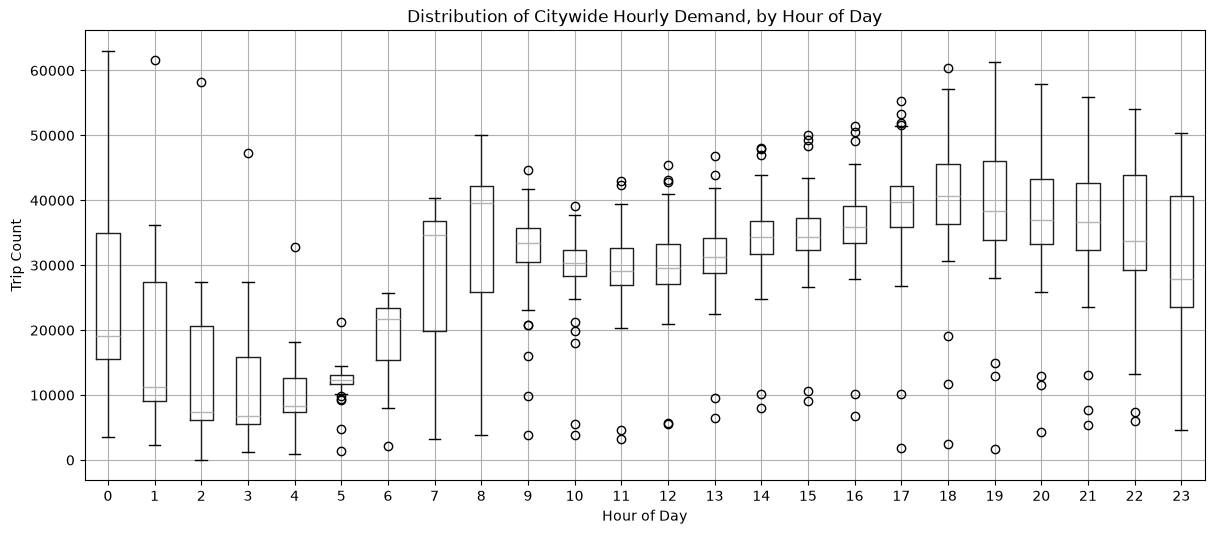

In [78]:
# Analyze the distribution of hourly trip counts across the dataset
hourly_distribution = con.sql("""
SELECT
    DATE_TRUNC('day', request_datetime) AS day,
    EXTRACT(HOUR FROM request_datetime) AS hour_of_day,
    COUNT(*) AS trip_count
FROM fhvhv_clean_2026
WHERE request_datetime >= '2026-01-01'
GROUP BY day, hour_of_day
ORDER BY hour_of_day, day
""").df()

plt.figure(figsize=(14, 6))
hourly_distribution.boxplot(column="trip_count", by="hour_of_day", ax=plt.gca())
plt.title("Distribution of Citywide Hourly Demand, by Hour of Day")
plt.suptitle("")
plt.xlabel("Hour of Day")
plt.ylabel("Trip Count")
plt.show()

Demand follows a clear daily pattern, with the lowest activity occurring in the early morning and a peak concentrated in the afternoon (12–5 PM). Midnight has greater variability, suggesting demand differs more across nights during this hour.

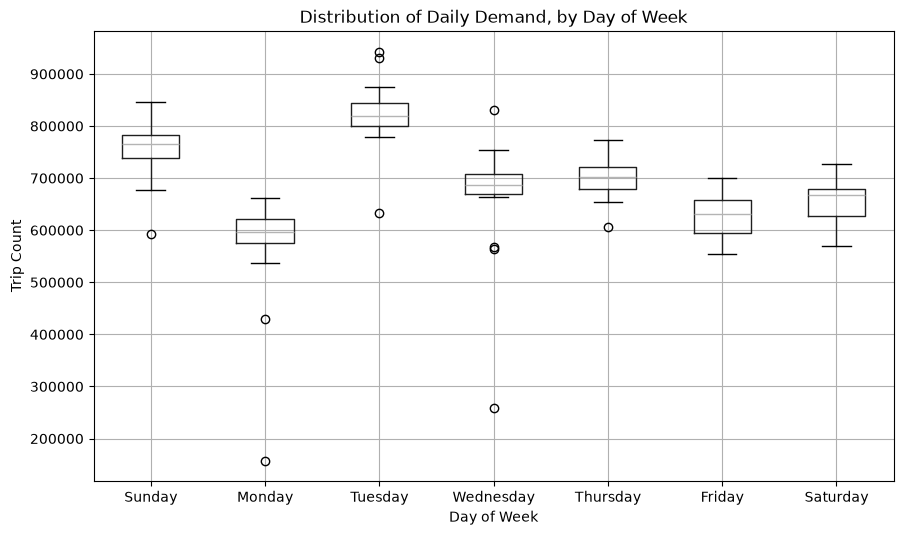

In [79]:
# Analyze the distribution of daily trip counts across the dataset
daily_totals = con.sql("""
    SELECT
        DATE_TRUNC('day', request_datetime) AS day,
        strftime(request_datetime, '%w') AS day_of_week,
        CASE strftime(request_datetime, '%w')
            WHEN '0' THEN 'Sunday' WHEN '1' THEN 'Monday' WHEN '2' THEN 'Tuesday'
            WHEN '3' THEN 'Wednesday' WHEN '4' THEN 'Thursday' WHEN '5' THEN 'Friday'
            WHEN '6' THEN 'Saturday'
        END AS day_name,
        COUNT(*) AS trip_count
    FROM fhvhv_clean_2026
    WHERE request_datetime >= '2026-01-01'
    GROUP BY day, day_of_week, day_name
""").df()

order = ["Sunday","Monday","Tuesday","Wednesday","Thursday","Friday","Saturday"]
plt.figure(figsize=(10, 6))
daily_totals.boxplot(column="trip_count", by="day_name", ax=plt.gca())
plt.gca().set_xticklabels(order)  # ensures calendar order, not alphabetical
plt.title("Distribution of Daily Demand, by Day of Week")
plt.suptitle("")
plt.xlabel("Day of Week")
plt.ylabel("Trip Count")
plt.show()

Tuesday has the highest median demand, while weekends are not the busiest as might be expected for a rideshare service. This suggests demand patterns do not simply follow a weekday vs. weekend trend. Monday shows lower demand due to several low-demand outliers.

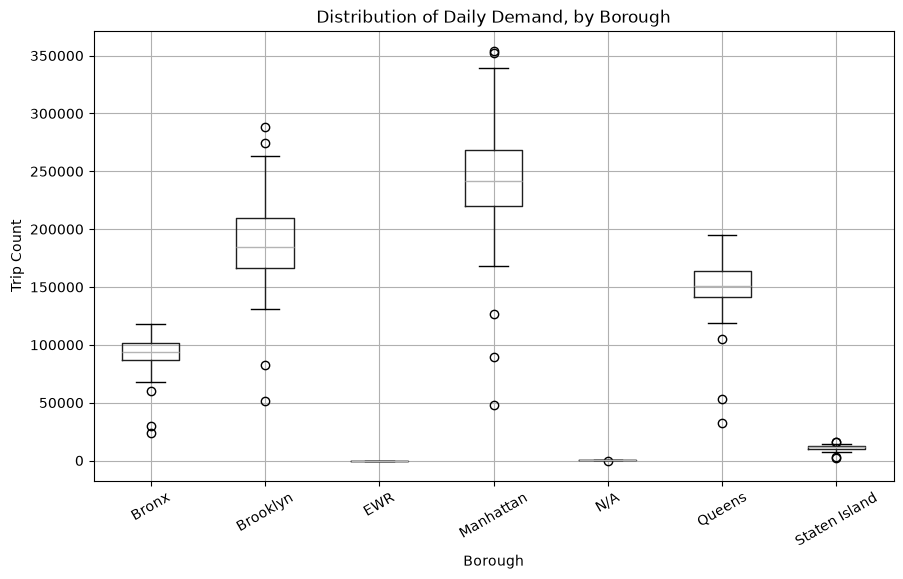

In [80]:
# Analyze the distribution of daily trip counts across the dataset, by borough
borough_daily = con.sql("""
    SELECT
        DATE_TRUNC('day', request_datetime) AS day,
        pickup_borough,
        COUNT(*) AS trip_count
    FROM fhvhv_clean_2026
    WHERE request_datetime >= '2026-01-01'
    GROUP BY day, pickup_borough
""").df()

plt.figure(figsize=(10, 6))
borough_daily.boxplot(column="trip_count", by="pickup_borough", ax=plt.gca())
plt.title("Distribution of Daily Demand, by Borough")
plt.suptitle("")
plt.xlabel("Borough")
plt.ylabel("Trip Count")
plt.xticks(rotation=30)
plt.show()

Manhattan has the highest median demand by a significant margin, followed by Brooklyn, Queens, the Bronx, and Staten Island. This aligns with expectations since Manhattan is the main business and tourism hub with higher population density and more transportation activity. 

## Temporal Patterns of High- and Low-Demand Zones

In [81]:
# Create a table that contains all combinations of zones and hours of the day, including those with zero demand
zone_hourly_spine = con.sql("""
CREATE OR REPLACE TEMP VIEW zone_hourly_spine AS

-- All distinct zones
WITH zones AS (
    SELECT DISTINCT pickup_zone
    FROM fhvhv_clean_2026
),

-- All distinct hours of the day
hours AS (
    SELECT DISTINCT EXTRACT(HOUR FROM request_datetime) AS hour_of_day
    FROM fhvhv_clean_2026
),

-- Combine zones and hours to get all possible combinations
all_zone_hour_combinations AS (
    SELECT
        z.pickup_zone,
        h.hour_of_day
    FROM zones z
    CROSS JOIN hours h
),

-- Count trips for each zone-hour combination
zone_hourly_counts AS (
    SELECT
        pickup_zone,
        EXTRACT(HOUR FROM request_datetime) AS hour_of_day,
        COUNT(*) AS trip_volume
    FROM fhvhv_clean_2026
    GROUP BY pickup_zone, hour_of_day
)

-- Join the combinations with the actual trip volume data, filling in zeros for missing combinations
SELECT
    a.pickup_zone,
    a.hour_of_day,
    COALESCE(f.trip_volume, 0) AS trip_volume
FROM all_zone_hour_combinations a
LEFT JOIN zone_hourly_counts f
    ON a.pickup_zone = f.pickup_zone
    AND a.hour_of_day = f.hour_of_day
ORDER BY a.pickup_zone, a.hour_of_day;
""")

In [82]:
# Get the top 10 zones with the highest total trip volume
high_demand_zones = con.sql("""
WITH highest_zones AS (
    SELECT
        pickup_zone
    FROM zone_hourly_spine
    GROUP BY pickup_zone
    ORDER BY SUM(trip_volume) DESC
    LIMIT 10
)

SELECT
    z.hour_of_day,
    z.pickup_zone,
    z.trip_volume
FROM zone_hourly_spine z
JOIN highest_zones l ON z.pickup_zone = l.pickup_zone
ORDER BY z.pickup_zone, z.hour_of_day;
""").df()

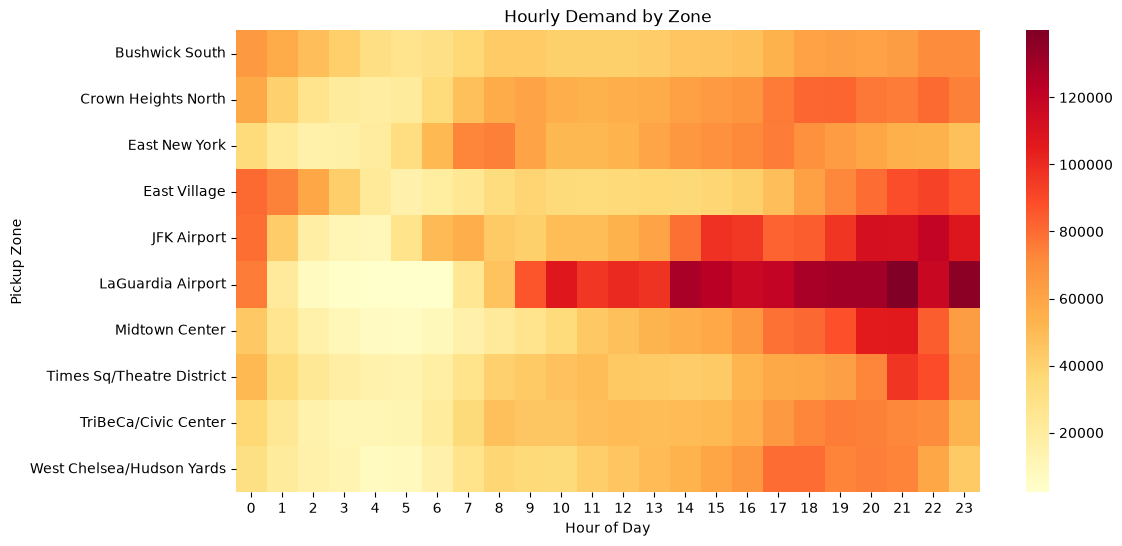

In [83]:
# Plot the hourly trip volume for the top 10 zones
pivot = high_demand_zones.pivot(
    index="pickup_zone",
    columns="hour_of_day",
    values="trip_volume"
)

plt.figure(figsize=(12, 6))
sns.heatmap(pivot, cmap="YlOrRd")

plt.xlabel("Hour of Day")
plt.ylabel("Pickup Zone")
plt.title("Hourly Demand by Zone")
plt.show()

Airport zones (LaGuardia and JFK) show consistently high demand from midday through late evening, while Manhattan areas like Midtown, Times Square, and TriBeCa have stronger demand peaks later in the evening.

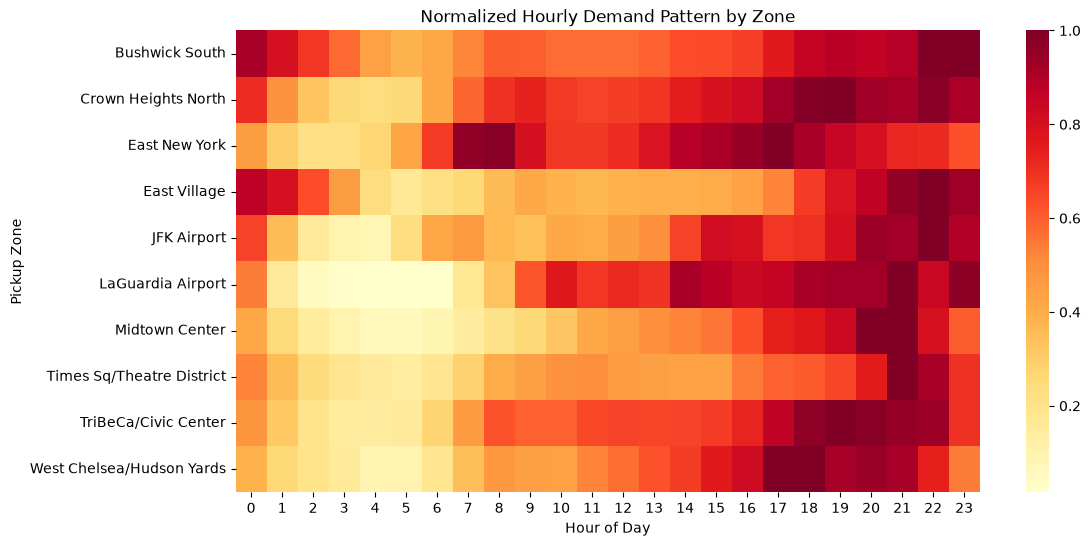

In [84]:
# Normalize the data for better comparison across zones
pivot = high_demand_zones.pivot(
    index="pickup_zone",
    columns="hour_of_day",
    values="trip_volume"
)

pivot_norm = pivot.div(pivot.max(axis=1), axis=0)

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_norm, cmap="YlOrRd")

plt.title("Normalized Hourly Demand Pattern by Zone")
plt.xlabel("Hour of Day")
plt.ylabel("Pickup Zone")
plt.show()

The normalized heatmap shows each zone's demand pattern relative to its own typical activity. Most zones have lower demand during early morning hours (around 1–7 AM) and higher demand from midday through midnight. Different zones peak at different times, showing that demand patterns vary by location rather than following one citywide trend.

In [85]:
# Get the bottom 10 zones with the lowest total trip volume
low_demand_zones = con.sql(f"""
WITH lowest_zones AS (
    SELECT
        pickup_zone
    FROM zone_hourly_spine
    GROUP BY pickup_zone
    ORDER BY SUM(trip_volume)
    LIMIT 10
)

SELECT
    z.hour_of_day,
    z.pickup_zone,
    z.trip_volume
FROM zone_hourly_spine z
JOIN lowest_zones l ON z.pickup_zone = l.pickup_zone
ORDER BY z.pickup_zone, z.hour_of_day;
""").df()

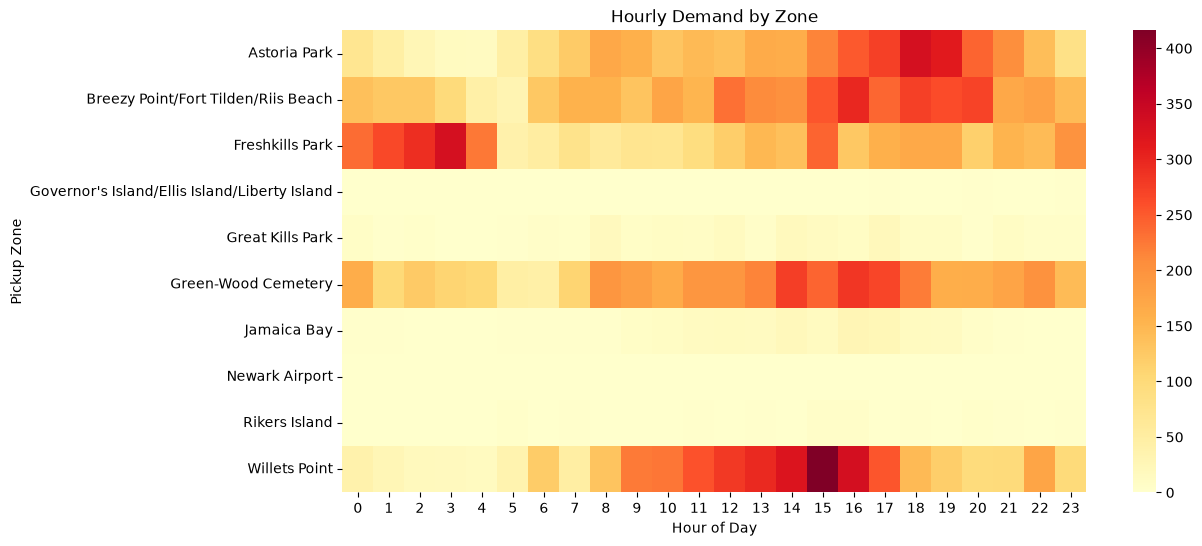

In [86]:
# Plot the hourly trip volume for the lowest 10 zones
pivot = low_demand_zones.pivot(
    index="pickup_zone",
    columns="hour_of_day",
    values="trip_volume"
)

plt.figure(figsize=(12, 6))
sns.heatmap(pivot, cmap="YlOrRd")

plt.xlabel("Hour of Day")
plt.ylabel("Pickup Zone")
plt.title("Hourly Demand by Zone")
plt.show()

The bottom-10 zones have significantly lower demand compared to the top zones. Their maximum hourly volume is only around 400 trips, compared to roughly 130,000 trips for the highest-demand zones, showing a large difference in activity levels across locations. This is expected since some zones have much lower population density, fewer attractions, and less transportation activity.

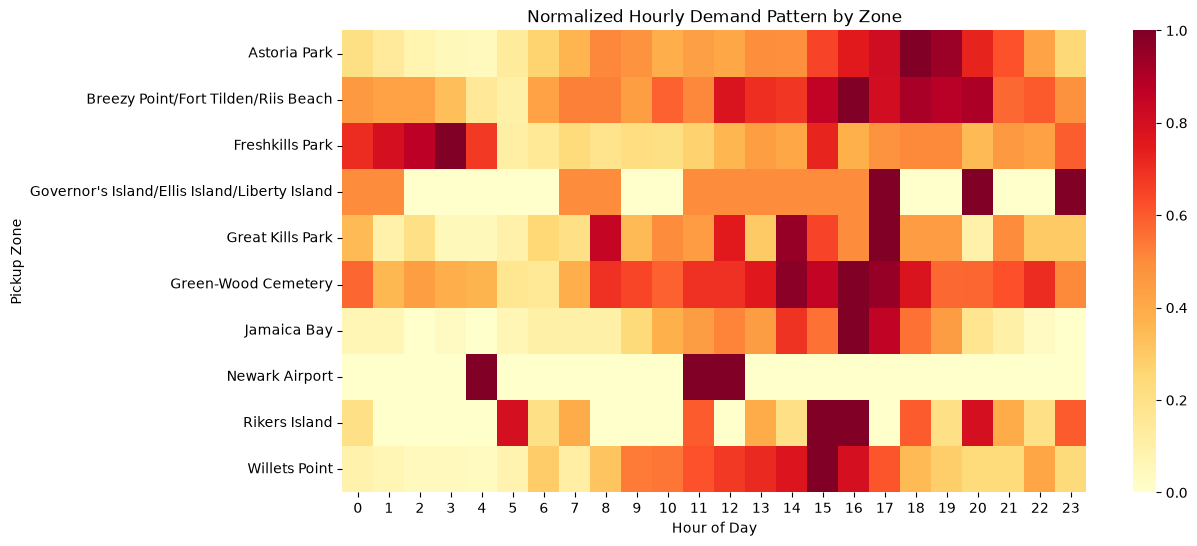

In [87]:
pivot = low_demand_zones.pivot(
    index="pickup_zone",
    columns="hour_of_day",
    values="trip_volume"
)

pivot_norm = pivot.div(pivot.max(axis=1), axis=0)

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_norm, cmap="YlOrRd")

plt.title("Normalized Hourly Demand Pattern by Zone")
plt.xlabel("Hour of Day")
plt.ylabel("Pickup Zone")
plt.show()

Low-volume zones show scattered peaks after normalization. Because these zones have fewer trips overall, small changes in trip counts can appear more significant on the heatmap.

## Daily Time-Series

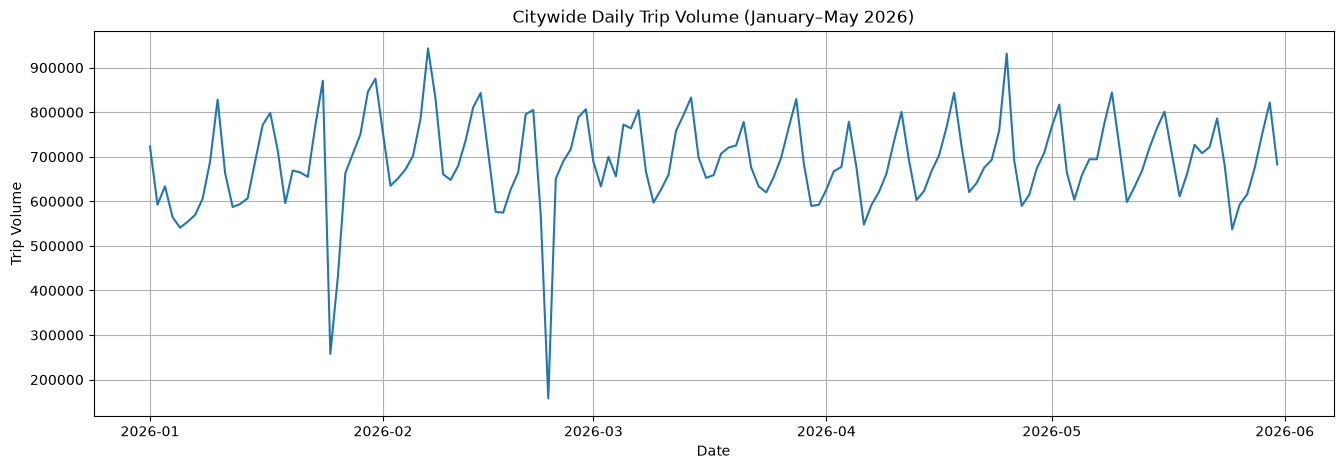

In [88]:
# Inspect citywide daily trip volume over time
daily_series = con.sql("""
SELECT
    DATE_TRUNC('day', request_datetime) AS day,
    COUNT(*) AS trip_count
FROM fhvhv_clean_2026
WHERE request_datetime >= '2026-01-01'  -- Exclude trips from December 2025 to focus on the analysis period
GROUP BY day
ORDER BY day;
""").df()

plt.figure(figsize=(16, 5))
plt.plot(daily_series["day"], daily_series["trip_count"])
plt.title("Citywide Daily Trip Volume (January–May 2026)")
plt.xlabel("Date")
plt.ylabel("Trip Volume")
plt.grid(True)
plt.show()

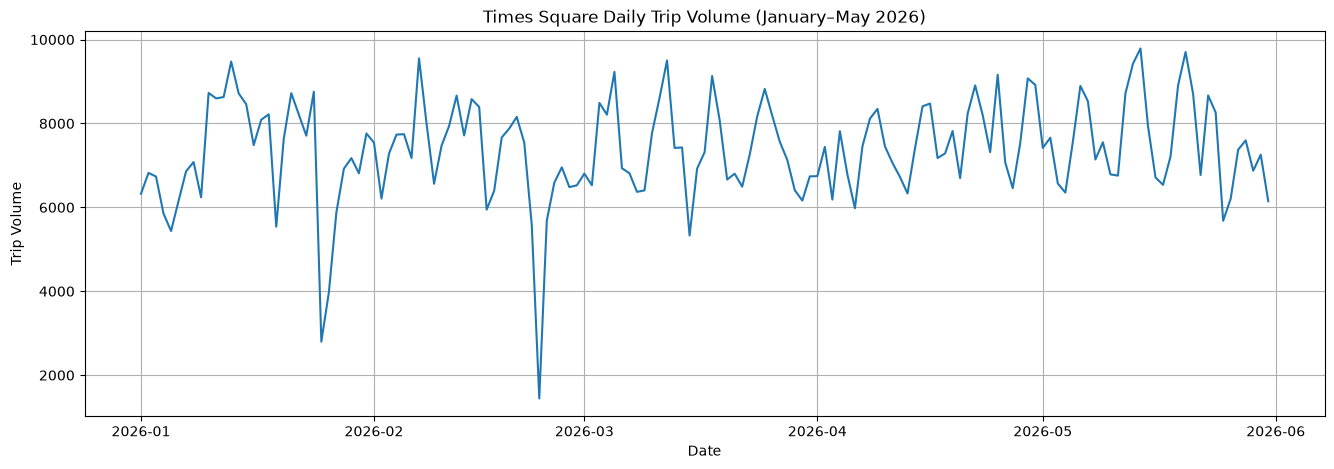

In [89]:
# Inspect daily trip volume over time for Times Square
times_square_daily = con.sql("""
SELECT
    DATE_TRUNC('day', request_datetime) AS day,
    COUNT(*) AS trip_count
FROM fhvhv_clean_2026
WHERE request_datetime >= '2026-01-01'
AND pickup_zone LIKE 'Times Sq%'
GROUP BY day
ORDER BY day;
""").df()

plt.figure(figsize=(16, 5))
plt.plot(times_square_daily["day"], times_square_daily["trip_count"])
plt.title("Times Square Daily Trip Volume (January–May 2026)")
plt.xlabel("Date")
plt.ylabel("Trip Volume")
plt.grid(True)
plt.show()

In [90]:
# Detect anomalies in daily trip volume using the Interquartile Range (IQR) method
# instead of using standard deviation, which can be sensitive to skewness
Q1 = daily_series["trip_count"].quantile(0.25)
Q3 = daily_series["trip_count"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

anomalies = daily_series[
    (daily_series["trip_count"] < lower) |
    (daily_series["trip_count"] > upper)
]

print(anomalies)

          day  trip_count
24 2026-01-25      257747
25 2026-01-26      430370
53 2026-02-23      157710


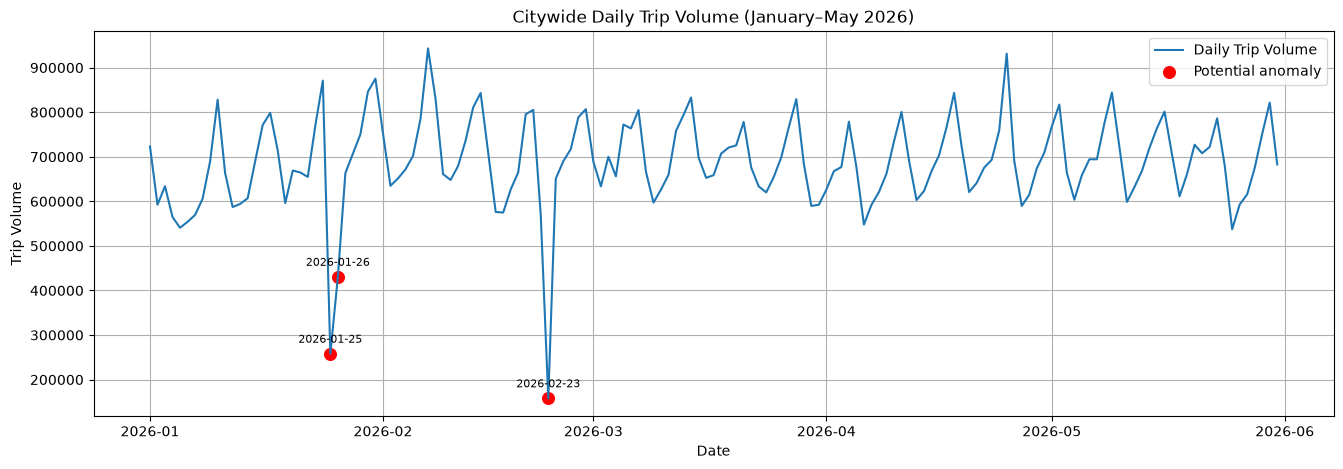

In [91]:
# Plot the daily trip volume with anomalies highlighted
plt.figure(figsize=(16, 5))

plt.plot(
    daily_series["day"],
    daily_series["trip_count"],
    label="Daily Trip Volume"
)

plt.scatter(
    anomalies["day"],
    anomalies["trip_count"],
    color="red",
    s=70,
    label="Potential anomaly"
)

# Annotate each anomaly
for _, row in anomalies.iterrows():
    plt.annotate(
        row["day"].strftime("%Y-%m-%d"),
        (row["day"], row["trip_count"]),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=8
    )

plt.title("Citywide Daily Trip Volume (January–May 2026)")
plt.xlabel("Date")
plt.ylabel("Trip Volume")
plt.grid(True)
plt.legend()

plt.show()

The anomaly check found three unusually low-demand days: Jan 25–26 and Feb 23. Outside of these drops, demand shows a consistent weekly pattern with no clear trend. The Times Square zone exhibits a similar temporal pattern to the overall citywide demand, suggesting that the observed daily and weekly seasonality is also present at the zone level. This supports focusing the model on capturing recurring temporal patterns while accounting for occasional demand shocks.

## ACF / PACF Plots

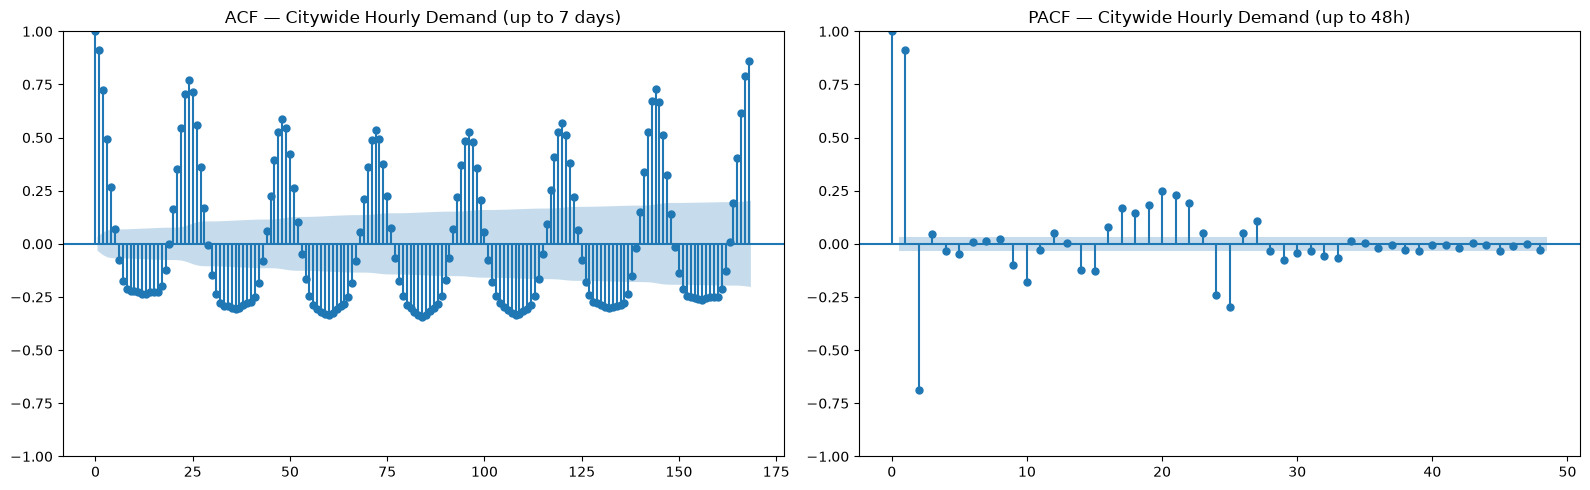

In [92]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Chronological hourly series
hourly_citywide = con.sql("""
    SELECT
        DATE_TRUNC('hour', request_datetime) AS hour_bucket,
        COUNT(*) AS trip_count
    FROM fhvhv_clean_2026
    GROUP BY hour_bucket
    ORDER BY hour_bucket
""").df().set_index("hour_bucket")["trip_count"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(hourly_citywide, lags=24 * 7, ax=axes[0])
axes[0].set_title("ACF — Citywide Hourly Demand (up to 7 days)")
plot_pacf(hourly_citywide, lags=48, ax=axes[1])
axes[1].set_title("PACF — Citywide Hourly Demand (up to 48h)")
plt.tight_layout()
plt.show()

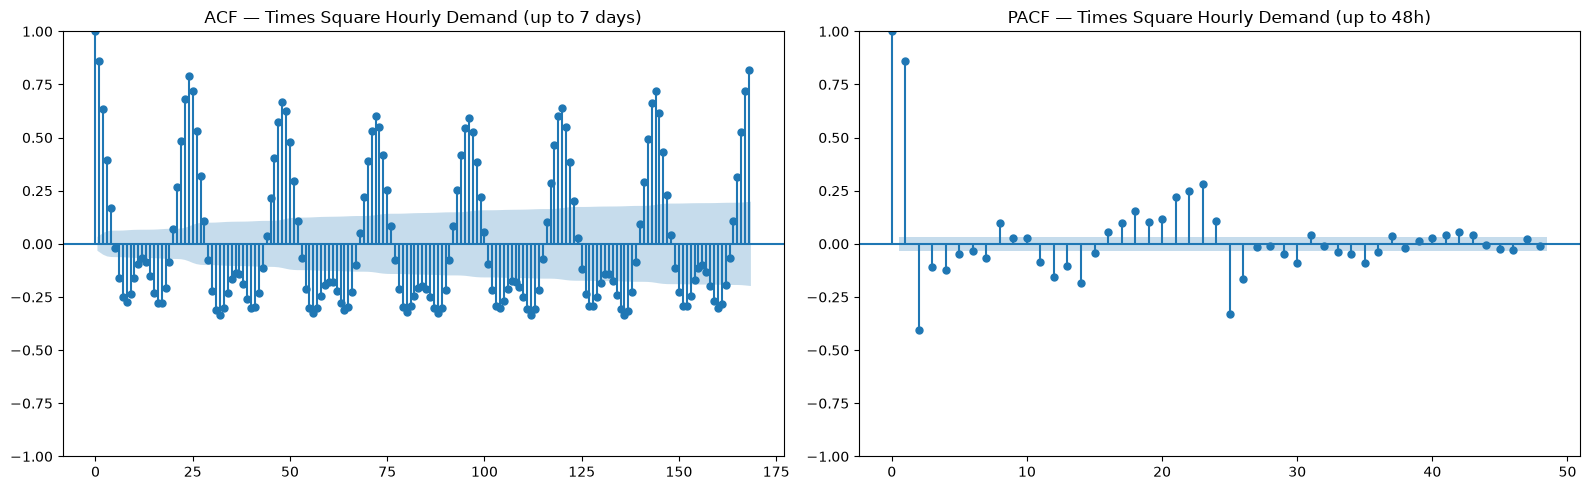

In [93]:
# ACF/PACF for Times Square
hourly_times_square = con.sql("""
    SELECT
        DATE_TRUNC('hour', request_datetime) AS hour_bucket,
        COUNT(*) AS trip_count
    FROM fhvhv_clean_2026
    WHERE pickup_zone LIKE 'Times Sq%'
    GROUP BY hour_bucket
    ORDER BY hour_bucket
""").df().set_index("hour_bucket")["trip_count"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(hourly_times_square, lags=24 * 7, ax=axes[0])
axes[0].set_title("ACF — Times Square Hourly Demand (up to 7 days)")
plot_pacf(hourly_times_square, lags=48, ax=axes[1])
axes[1].set_title("PACF — Times Square Hourly Demand (up to 48h)")
plt.tight_layout()
plt.show()

The ACF shows strong spikes every 24 hours, indicating a daily demand pattern. The PACF drops off after lag 2, suggesting that the previous two hours are the most important short-term predictors. Therefore, an AR(2) component with seasonal terms is a reasonable modeling approach.

----

### What This Means for Modeling

- **Use hourly demand:** Demand should be aggregated by request hour.
- **Use historical demand:** ACF/PACF show that past demand contains predictive information.
- **Account for daily seasonality:** The strong 24-hour ACF pattern supports a seasonal forecasting approach.
- **Keep anomalies:** Unusual demand days should be retained and considered during modeling.
- **Use a naive baseline:** Compare SARIMA against the same-hour-last-week forecast.

In [94]:
con.close()